# 能源数据合并处理

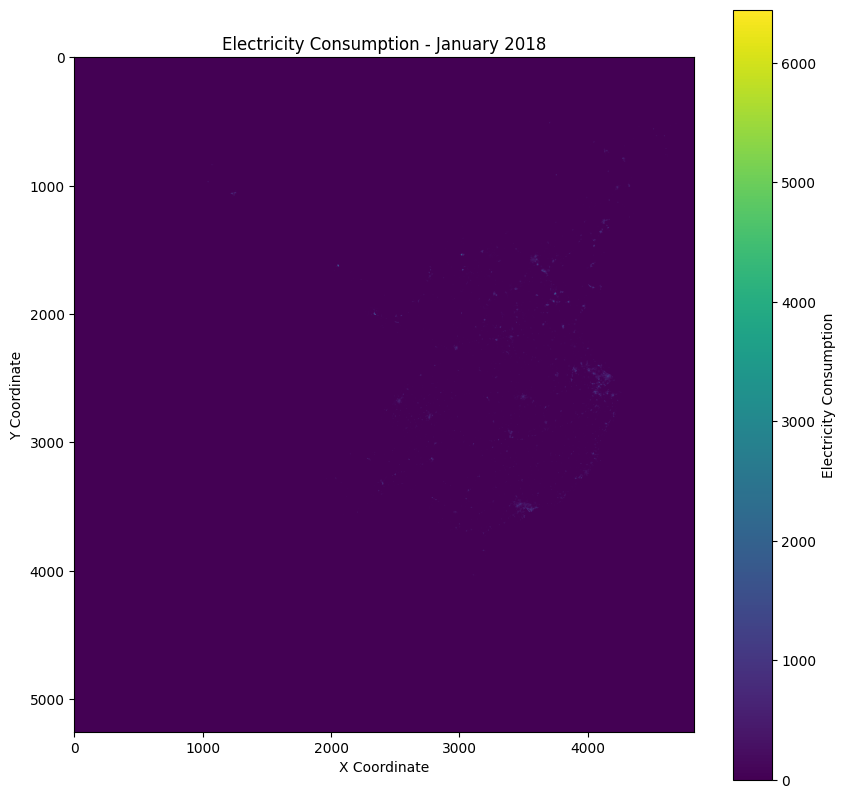

In [4]:
# pip install rasterio matplotlib

import rasterio
import matplotlib.pyplot as plt

# 读取 .tif 文件
file_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\China_1km_Ele_201204_201912\201801.tif'
with rasterio.open(file_path) as src:
    data = src.read(1)  # 读取第一个波段

# 可视化数据
plt.figure(figsize=(10, 10))
plt.imshow(data, cmap='viridis')
plt.colorbar(label='Electricity Consumption')
plt.title('Electricity Consumption - January 2018')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# 裁剪武汉市区域的数据

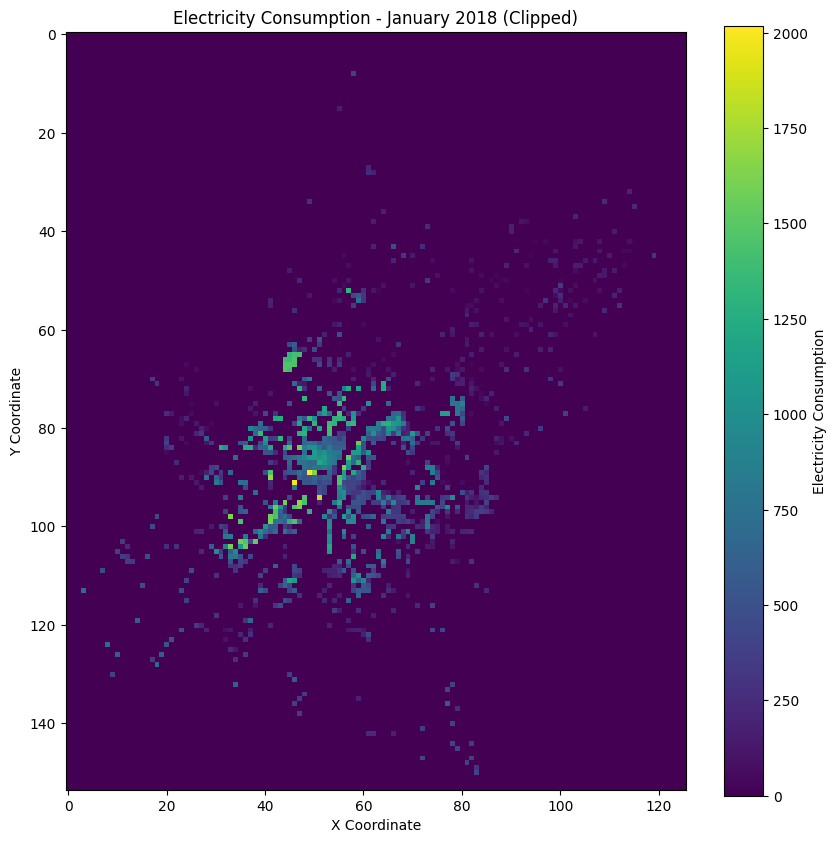

In [6]:
# 裁剪武汉市区域的数据

# pip install rasterio geopandas matplotlib

import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取 .tif 文件
tif_file_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\China_1km_Ele_201204_201912\201801.tif'
with rasterio.open(tif_file_path) as src:
    raster_data = src.read(1)  # 读取第一个波段
    raster_crs = src.crs  # 获取栅格数据的 CRS

# 读取 .shp 文件
shp_file_path = r'F:\ScientificDatabase\paper02_use\wuhan_shape_real.shp'
shapefile = gpd.read_file(shp_file_path)

# 检查并转换 shapefile 的 CRS
if shapefile.crs != raster_crs:
    shapefile = shapefile.to_crs(raster_crs)

# 将 shapefile 转换为 GeoJSON 格式
shapes = [feature["geometry"] for feature in shapefile.__geo_interface__["features"]]

# 使用 shapefile 轮廓裁剪栅格数据
with rasterio.open(tif_file_path) as src:
    out_image, out_transform = mask(src, shapes, crop=True)
    out_meta = src.meta.copy()

# 更新元数据以反映裁剪后的数据
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# 可视化裁剪后的数据
plt.figure(figsize=(10, 10))
plt.imshow(out_image[0], cmap='viridis')
plt.colorbar(label='Electricity Consumption')
plt.title('Electricity Consumption - January 2018 (Clipped)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

In [7]:
# ...existing code...

# 保存裁剪后的数据
output_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\China_1km_Ele_201204_201912\201801_wuhan_clipped.tif'
with rasterio.open(output_path, 'w', **out_meta) as dest:
    dest.write(out_image)

# 可视化裁剪后的数据
plt.figure(figsize=(10, 10))
# ...existing code...

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

# 批量处理能源数据并且合并

In [8]:
# 批量处理能源数据并且合并

import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from glob import glob

# 基础路径设置
base_input_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\China_1km_Ele_201204_201912'
base_output_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped'

# 创建输出目录（如果不存在）
if not os.path.exists(base_output_path):
    os.makedirs(base_output_path)

# 读取 shapefile
shp_file_path = r'F:\ScientificDatabase\paper02_use\wuhan_shape_real.shp'
shapefile = gpd.read_file(shp_file_path)

# 处理2018年的所有月份
for month in range(1, 13):
    # 构建输入文件路径
    input_filename = f'2018{month:02d}.tif'
    input_path = os.path.join(base_input_path, input_filename)
    
    # 构建输出文件路径
    output_filename = f'2018{month:02d}_wuhan_clipped.tif'
    output_path = os.path.join(base_output_path, output_filename)
    
    print(f'处理文件: {input_filename}')
    
    try:
        # 读取栅格数据并获取 CRS
        with rasterio.open(input_path) as src:
            raster_crs = src.crs
            
            # 确保 shapefile 使用相同的 CRS
            if shapefile.crs != raster_crs:
                shapefile = shapefile.to_crs(raster_crs)
            
            # 准备裁剪形状
            shapes = [feature["geometry"] for feature in shapefile.__geo_interface__["features"]]
            
            # 执行裁剪
            out_image, out_transform = mask(src, shapes, crop=True)
            out_meta = src.meta.copy()
            
            # 更新元数据
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            
            # 保存裁剪后的数据
            with rasterio.open(output_path, 'w', **out_meta) as dest:
                dest.write(out_image)
                
            print(f'已保存: {output_filename}')
            
    except Exception as e:
        print(f'处理 {input_filename} 时出错: {str(e)}')

print('批量处理完成!')

处理文件: 201801.tif
已保存: 201801_wuhan_clipped.tif
处理文件: 201802.tif
已保存: 201802_wuhan_clipped.tif
处理文件: 201803.tif
已保存: 201803_wuhan_clipped.tif
处理文件: 201804.tif
已保存: 201804_wuhan_clipped.tif
处理文件: 201805.tif
已保存: 201805_wuhan_clipped.tif
处理文件: 201806.tif
已保存: 201806_wuhan_clipped.tif
处理文件: 201807.tif
已保存: 201807_wuhan_clipped.tif
处理文件: 201808.tif
已保存: 201808_wuhan_clipped.tif
处理文件: 201809.tif
已保存: 201809_wuhan_clipped.tif
处理文件: 201810.tif
已保存: 201810_wuhan_clipped.tif
处理文件: 201811.tif
已保存: 201811_wuhan_clipped.tif
处理文件: 201812.tif
已保存: 201812_wuhan_clipped.tif
批量处理完成!


已合并波段 1: 201801_wuhan_clipped.tif
已合并波段 2: 201802_wuhan_clipped.tif
已合并波段 3: 201803_wuhan_clipped.tif
已合并波段 4: 201804_wuhan_clipped.tif
已合并波段 5: 201805_wuhan_clipped.tif
已合并波段 6: 201806_wuhan_clipped.tif
已合并波段 7: 201807_wuhan_clipped.tif
已合并波段 8: 201808_wuhan_clipped.tif
已合并波段 9: 201809_wuhan_clipped.tif
已合并波段 10: 201810_wuhan_clipped.tif
已合并波段 11: 201811_wuhan_clipped.tif
已合并波段 12: 201812_wuhan_clipped.tif

合并完成！文件已保存为: F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined.tif

验证结果:
波段数量: 12
数据形状: (154, 126)


d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


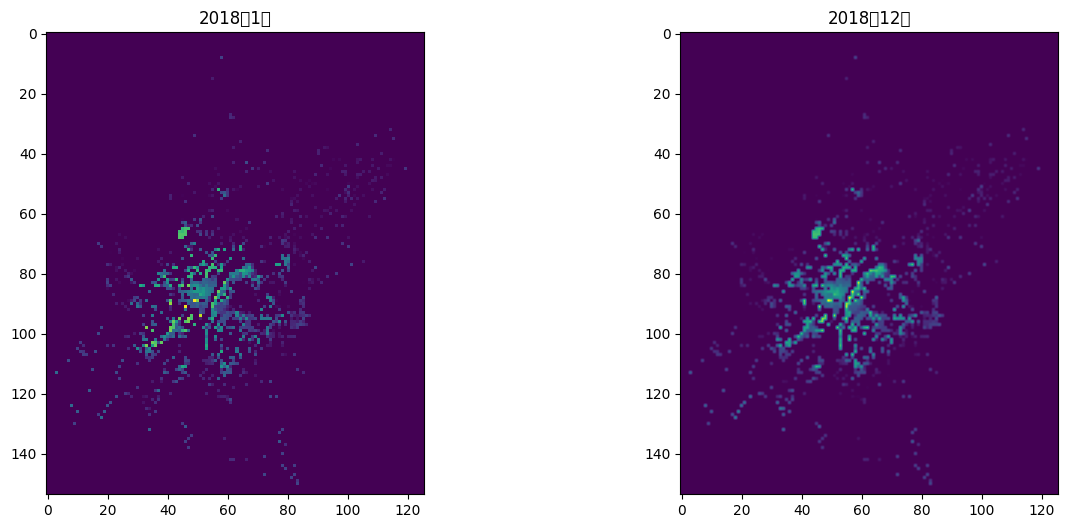

In [9]:
import rasterio
import numpy as np
from glob import glob
import os

# 设置输入和输出路径
input_dir = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped'
output_file = os.path.join(input_dir, 'wuhan_2018_combined.tif')

# 获取所有裁剪后的文件并排序
input_files = sorted(glob(os.path.join(input_dir, '2018*_wuhan_clipped.tif')))

# 读取第一个文件来获取元数据
with rasterio.open(input_files[0]) as src:
    meta = src.meta.copy()

# 更新元数据以支持多波段
meta.update({
    'count': len(input_files),  # 更新为12个波段
    'driver': 'GTiff'
})

# 创建输出文件并写入数据
with rasterio.open(output_file, 'w', **meta) as dst:
    # 逐个读取文件并写入相应的波段
    for idx, file_path in enumerate(input_files, start=1):
        with rasterio.open(file_path) as src:
            dst.write(src.read(1), idx)
        print(f'已合并波段 {idx}: {os.path.basename(file_path)}')

print(f'\n合并完成！文件已保存为: {output_file}')

# 验证合并后的数据
with rasterio.open(output_file) as src:
    print(f'\n验证结果:')
    print(f'波段数量: {src.count}')
    print(f'数据形状: {src.shape}')
    
    # 可视化第一个月和最后一个月的数据对比
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 显示第一个月的数据
    ax1.imshow(src.read(1), cmap='viridis')
    ax1.set_title('2018年1月')
    
    # 显示最后一个月的数据
    ax2.imshow(src.read(12), cmap='viridis')
    ax2.set_title('2018年12月')
    
    plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_01' to 'ele_2018_0'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)


已保存 2018_01 的矢量数据
已保存 2018_02 的矢量数据
已保存 2018_03 的矢量数据


d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_02' to 'ele_2018_0'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_03' to 'ele_2018_0'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_04' to 'ele_2018_0'
  ogr_write(


已保存 2018_04 的矢量数据
已保存 2018_05 的矢量数据
已保存 2018_06 的矢量数据


C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_05' to 'ele_2018_0'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_06' to 'ele_2018_0'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: No

已保存 2018_07 的矢量数据
已保存 2018_08 的矢量数据
已保存 2018_09 的矢量数据


d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_10' to 'ele_2018_1'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_11' to 'ele_2018_1'
  ogr_write(
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3116912370.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_12' to 'ele_2018_1'
  ogr_write(


已保存 2018_10 的矢量数据
已保存 2018_11 的矢量数据
已保存 2018_12 的矢量数据
转换完成！
可用的列名: ['ele_2018_0', 'geometry']


d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37327 (\N{CJK UNIFIE

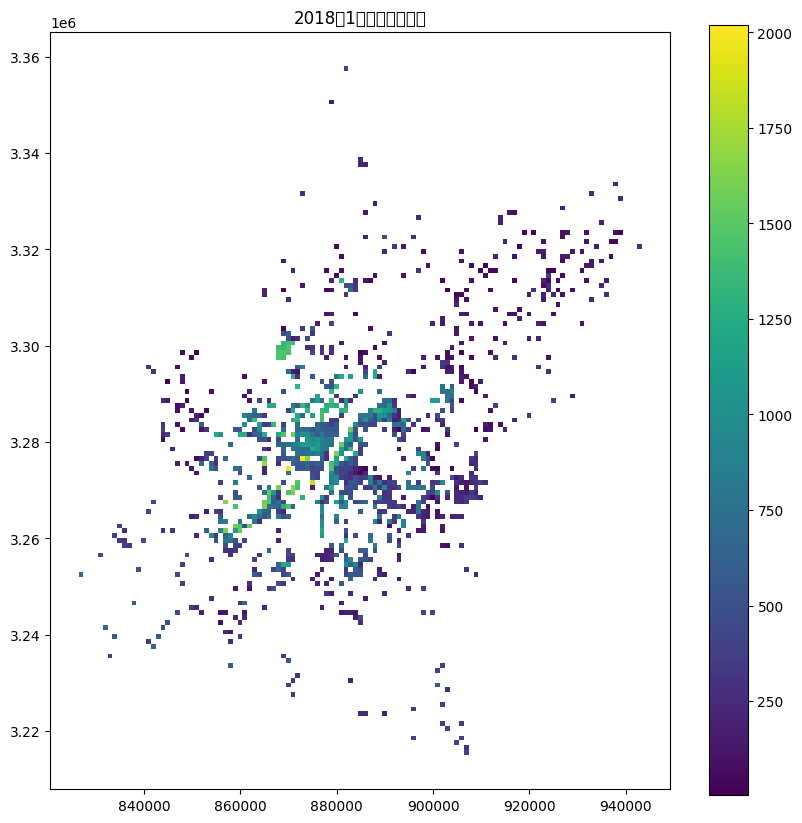

In [11]:
import rasterio
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def raster_to_vector(raster_data, transform, band_name='value'):
    """将栅格数据转换为矢量多边形"""
    # 创建掩码，忽略NoData值
    mask = ~np.isnan(raster_data)
    
    # 使用rasterio的features提取多边形
    shapes = features.shapes(
        raster_data.astype('float32'),
        mask=mask,
        transform=transform
    )
    
    # 转换为GeoDataFrame
    geometries = []
    values = []
    
    for geom, value in shapes:
        if value > 0:  # 只保留有值的区域
            geometries.append(shape(geom))
            values.append(float(value))
    
    gdf = gpd.GeoDataFrame({
        band_name: values,
        'geometry': geometries
    }, crs=raster_crs)
    
    return gdf

# 读取合并后的栅格文件
raster_path = os.path.join(input_dir, 'wuhan_2018_combined.tif')
with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    # 处理每个波段（月份）
    for band in range(1, src.count + 1):
        # 读取波段数据
        band_data = src.read(band)
        month = f'2018_{band:02d}'
        column_name = f'ele_{month}'  # 存储列名
        
        # 转换为矢量
        gdf = raster_to_vector(band_data, src.transform, column_name)
        
        # 保存为shapefile
        output_shp = os.path.join(input_dir, f'wuhan_ele_{month}.shp')
        gdf.to_file(output_shp)
        print(f'已保存 {month} 的矢量数据')

print('转换完成！')

# 显示第一个月的矢量数据示例
example_shp = os.path.join(input_dir, 'wuhan_ele_2018_01.shp')
gdf_example = gpd.read_file(example_shp)

# 打印列名，用于调试
print("可用的列名:", gdf_example.columns.tolist())

# 使用实际的列名绘图
fig, ax = plt.subplots(figsize=(10, 10))
value_column = gdf_example.columns[0]  # 假设第一列是值列
gdf_example.plot(column=value_column, cmap='viridis', legend=True, ax=ax)
plt.title('2018年1月用电量矢量图')
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3440878416.py:51: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_shp)
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_01' to 'ele_2018_0'
  ogr_write(
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_02' to 'ele_2018_1'
  ogr_write(
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_03' to 'ele_2018_2'
  ogr_write(
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_04' to 'ele_2018_3'
  ogr_write(
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ele_2018_05' to 'ele_201

转换完成！

数据概览：
   ele_2018_01  ele_2018_02  ele_2018_03  ele_2018_04  ele_2018_05  \
0          0.0          0.0          0.0          0.0          0.0   
1          0.0          0.0          0.0          0.0          0.0   
2          0.0          0.0          0.0          0.0          0.0   
3          0.0          0.0          0.0          0.0          0.0   
4          0.0          0.0          0.0          0.0          0.0   

   ele_2018_06  ele_2018_07  ele_2018_08  ele_2018_09  ele_2018_10  \
0          0.0          0.0          0.0          0.0          0.0   
1          0.0          0.0          0.0          0.0          0.0   
2          0.0          0.0          0.0          0.0          0.0   
3          0.0          0.0          0.0          0.0          0.0   
4          0.0          0.0          0.0          0.0          0.0   

   ele_2018_11  ele_2018_12                        geometry  
0          0.0          0.0  POINT (823914.168 3365546.345)  
1          0.0       

d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
d:\Anaconda\anaconda3\envs\gis_env\lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  ax.figure.canv

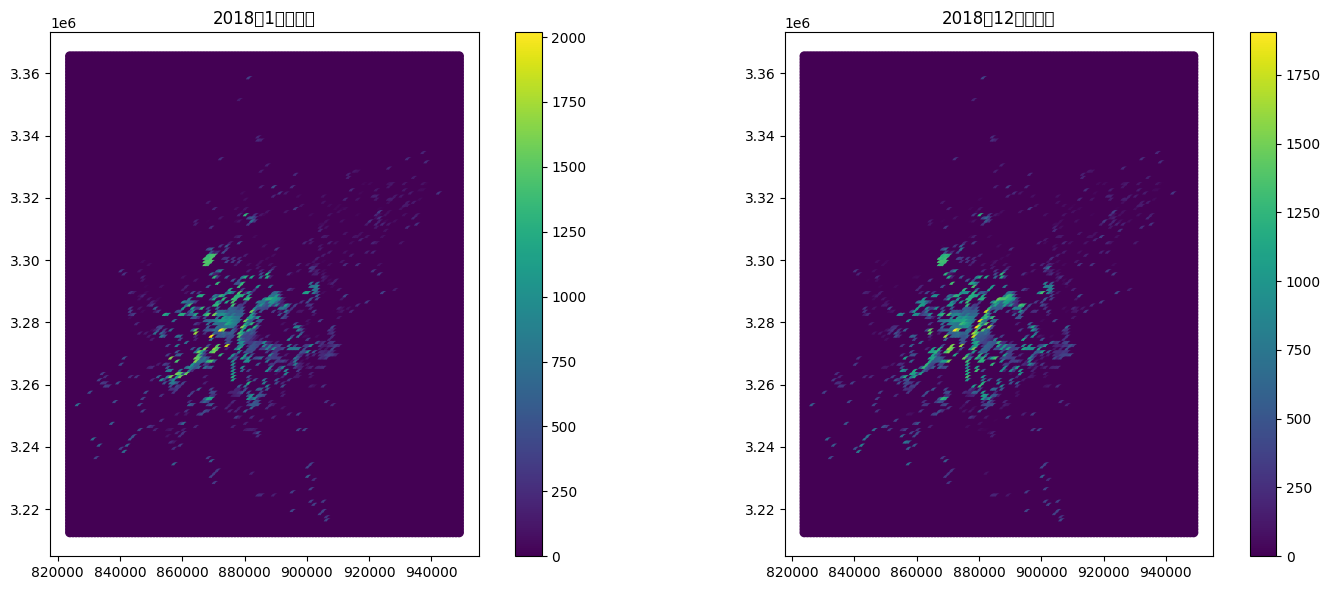

In [12]:
import rasterio
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def raster_to_vector_multibands(raster_path):
    """将多波段栅格转换为单个矢量文件，每个波段作为一个属性列"""
    with rasterio.open(raster_path) as src:
        # 获取基本信息
        raster_crs = src.crs
        band_count = src.count
        
        # 读取第一个波段来创建基础几何形状
        band1_data = src.read(1)
        mask = ~np.isnan(band1_data)
        
        # 创建几何形状和值的字典
        geometries = []
        values_dict = {f'ele_2018_{i:02d}': [] for i in range(1, band_count + 1)}
        
        # 获取像素坐标和值
        rows, cols = np.where(mask)
        for row, col in zip(rows, cols):
            # 获取像素中心坐标
            x, y = rasterio.transform.xy(src.transform, row, col)
            pixel_geom = shape({'type': 'Point', 'coordinates': (x, y)})
            geometries.append(pixel_geom)
            
            # 获取每个波段在该位置的值
            for band in range(1, band_count + 1):
                band_data = src.read(band)
                value = float(band_data[row, col])
                values_dict[f'ele_2018_{band:02d}'].append(value)
    
    # 创建GeoDataFrame
    data = values_dict
    data['geometry'] = geometries
    gdf = gpd.GeoDataFrame(data, crs=raster_crs)
    
    return gdf

# 读取合并后的栅格文件并转换
raster_path = os.path.join(input_dir, 'wuhan_2018_combined.tif')
gdf = raster_to_vector_multibands(raster_path)

# 保存为单个shapefile
output_shp = os.path.join(input_dir, 'wuhan_ele_2018_all_months.shp')
gdf.to_file(output_shp)
print('转换完成！')

# 显示数据概览
print("\n数据概览：")
print(gdf.head())
print("\n列名：", gdf.columns.tolist())

# 可视化第一个月和最后一个月的对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 第一个月
gdf.plot(column='ele_2018_01', cmap='viridis', legend=True, ax=ax1)
ax1.set_title('2018年1月用电量')

# 最后一个月
gdf.plot(column='ele_2018_12', cmap='viridis', legend=True, ax=ax2)
ax2.set_title('2018年12月用电量')

plt.tight_layout()
plt.show()

# 边界裁剪

裁剪完成！


C:\Users\asus\AppData\Local\Temp\ipykernel_54972\806971088.py:65: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\806971088.py:65: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\806971088.py:65: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\806971088.py:65: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\806971088.py:65: UserWarning: Glyph 35009 (\N{CJK UNIFIED IDEOGRAPH-88C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\806971088.py:65: UserWarning: Glyph 21098 (\N{CJK UNIFIE

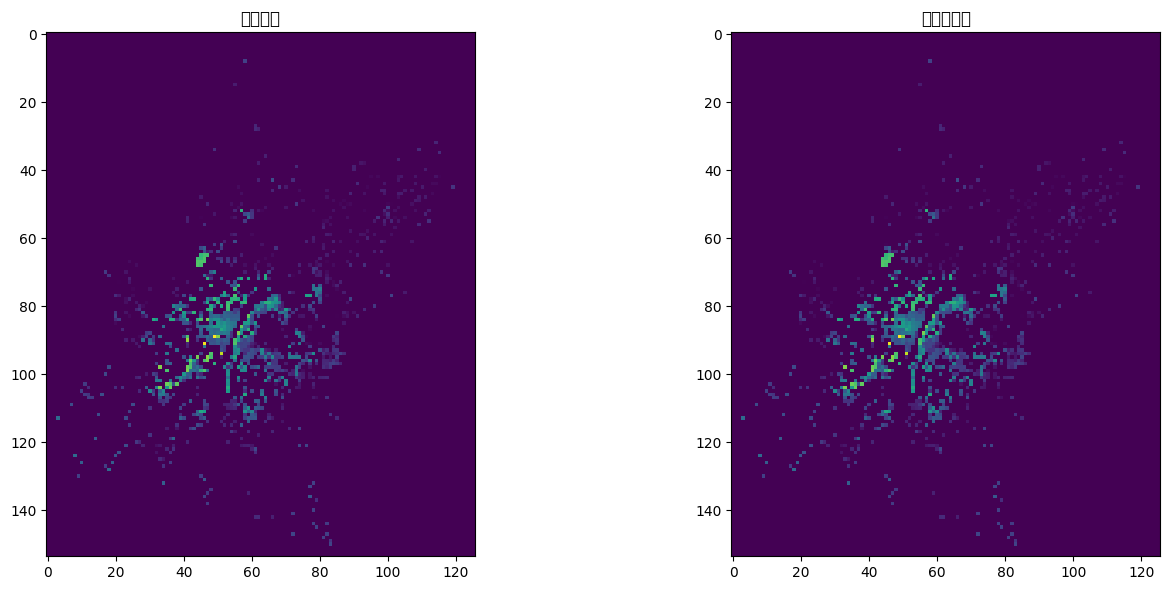


数据概览：
原始数据形状：(154, 126)
裁剪后数据形状：(154, 126)


In [14]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clip_raster_with_boundary(raster_path, boundary_path):
    """使用边界裁剪栅格数据"""
    # 读取边界数据
    boundary = gpd.read_file(boundary_path)
    
    # 读取栅格数据
    with rasterio.open(raster_path) as src:
        # 确保边界和栅格使用相同的CRS
        if boundary.crs != src.crs:
            boundary = boundary.to_crs(src.crs)
        
        # 准备裁剪形状
        shapes = boundary.geometry.values
        
        # 执行裁剪
        out_image, out_transform = mask(src, shapes, crop=True)
        out_meta = src.meta.copy()
        
        # 更新元数据
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        return out_image, out_meta

# 设置输入输出路径
raster_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined.tif'
boundary_path = r'F:\ScientificDatabase\paper02_use\wuhan_shape_real.shp'
output_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined_masked.tif'

# 执行裁剪
clipped_data, meta = clip_raster_with_boundary(raster_path, boundary_path)

# 保存裁剪后的数据
with rasterio.open(output_path, 'w', **meta) as dest:
    dest.write(clipped_data)

print("裁剪完成！")

# 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 原始数据
with rasterio.open(raster_path) as src:
    original = src.read(1)  # 显示第一个月的数据
    ax1.imshow(original, cmap='viridis')
    ax1.set_title('原始数据')

# 裁剪后的数据
with rasterio.open(output_path) as src:
    clipped = src.read(1)  # 显示第一个月的数据
    ax2.imshow(clipped, cmap='viridis')
    ax2.set_title('裁剪后数据')

plt.tight_layout()
plt.show()

# 打印一些基本信息
print("\n数据概览：")
print(f"原始数据形状：{original.shape}")
print(f"裁剪后数据形状：{clipped.shape}")

C:\Users\asus\AppData\Local\Temp\ipykernel_54972\1830237482.py:65: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\1830237482.py:65: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\1830237482.py:65: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\1830237482.py:65: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\1830237482.py:65: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\1830237482.py:65: UserWarning: Glyph 24180 (\N{CJK 

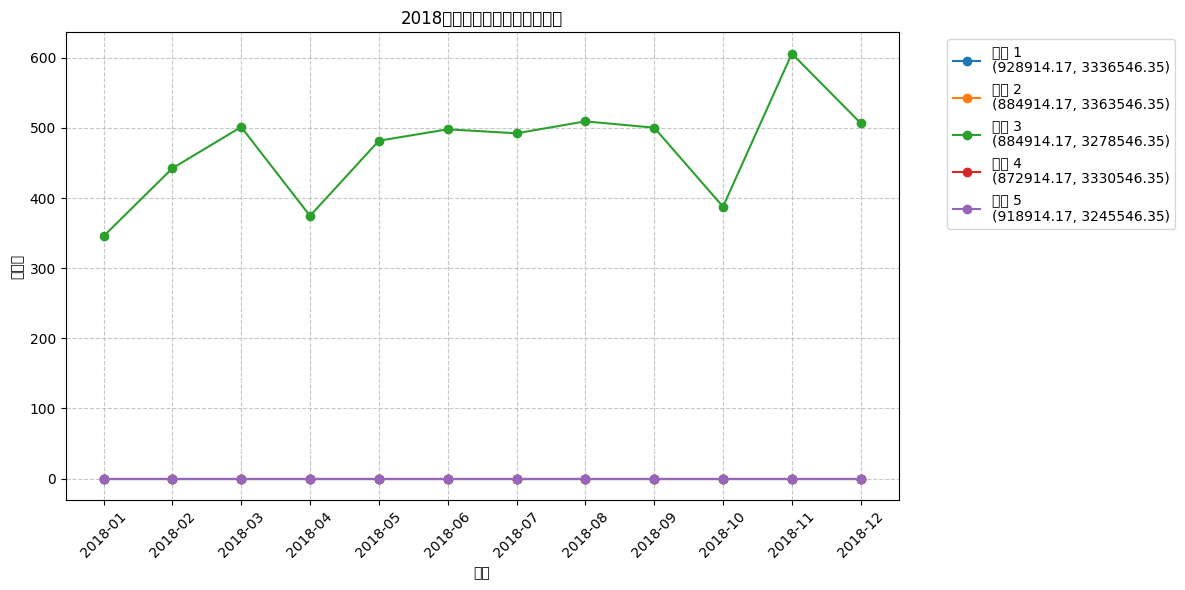


随机点位数据概览：
         2018-01     2018-02     2018-03     2018-04     2018-05     2018-06  \
点位 1    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
点位 2    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
点位 3  345.465139  442.357993  501.217896  374.528811  481.615124  497.904784   
点位 4    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
点位 5    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   

         2018-07    2018-08     2018-09     2018-10     2018-11     2018-12  
点位 1    0.000000    0.00000    0.000000    0.000000    0.000000    0.000000  
点位 2    0.000000    0.00000    0.000000    0.000000    0.000000    0.000000  
点位 3  492.217424  509.24719  500.218589  387.577236  605.836656  506.613044  
点位 4    0.000000    0.00000    0.000000    0.000000    0.000000    0.000000  
点位 5    0.000000    0.00000    0.000000    0.000000    0.000000    0.000000  


In [15]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

def extract_random_points(raster_path, num_points=5):
    """随机提取点位的时间序列数据"""
    with rasterio.open(raster_path) as src:
        # 读取所有波段数据
        data = src.read()
        
        # 获取有效数据的位置（非NoData）
        valid_mask = ~np.isnan(data[0])  # 使用第一个波段来确定有效位置
        valid_positions = np.where(valid_mask)
        
        # 随机选择点位
        num_valid = len(valid_positions[0])
        selected_indices = random.sample(range(num_valid), min(num_points, num_valid))
        
        # 提取每个选定点位的时间序列数据
        time_series = []
        coordinates = []
        
        for idx in selected_indices:
            row = valid_positions[0][idx]
            col = valid_positions[1][idx]
            
            # 获取地理坐标
            x, y = src.xy(row, col)
            coordinates.append((x, y))
            
            # 获取所有波段的值
            values = [data[band, row, col] for band in range(data.shape[0])]
            time_series.append(values)
            
        return np.array(time_series), coordinates

# 读取裁剪后的数据
raster_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined_masked.tif'

# 提取随机点位数据
n_points = 5  # 设置要提取的点数
time_series, coordinates = extract_random_points(raster_path, n_points)

# 创建月份标签
months = [f'2018-{i:02d}' for i in range(1, 13)]

# 创建图表
plt.figure(figsize=(12, 6))

# 绘制每个点位的时间序列
for i in range(len(time_series)):
    plt.plot(months, time_series[i], marker='o', label=f'点位 {i+1}\n({coordinates[i][0]:.2f}, {coordinates[i][1]:.2f})')

# 设置图表属性
plt.xlabel('月份')
plt.ylabel('用电量')
plt.title('2018年随机点位月度用电量变化')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 调整布局以显示完整的图例
plt.tight_layout()
plt.show()

# 打印数据表格
df = pd.DataFrame(time_series, 
                 columns=months,
                 index=[f'点位 {i+1}' for i in range(len(time_series))])
print("\n随机点位数据概览：")
print(df)

C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3666685856.py:91: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3666685856.py:91: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3666685856.py:91: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3666685856.py:91: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3666685856.py:91: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_54972\3666685856.py:91: UserWarning: Glyph 20998 (\N{CJK 

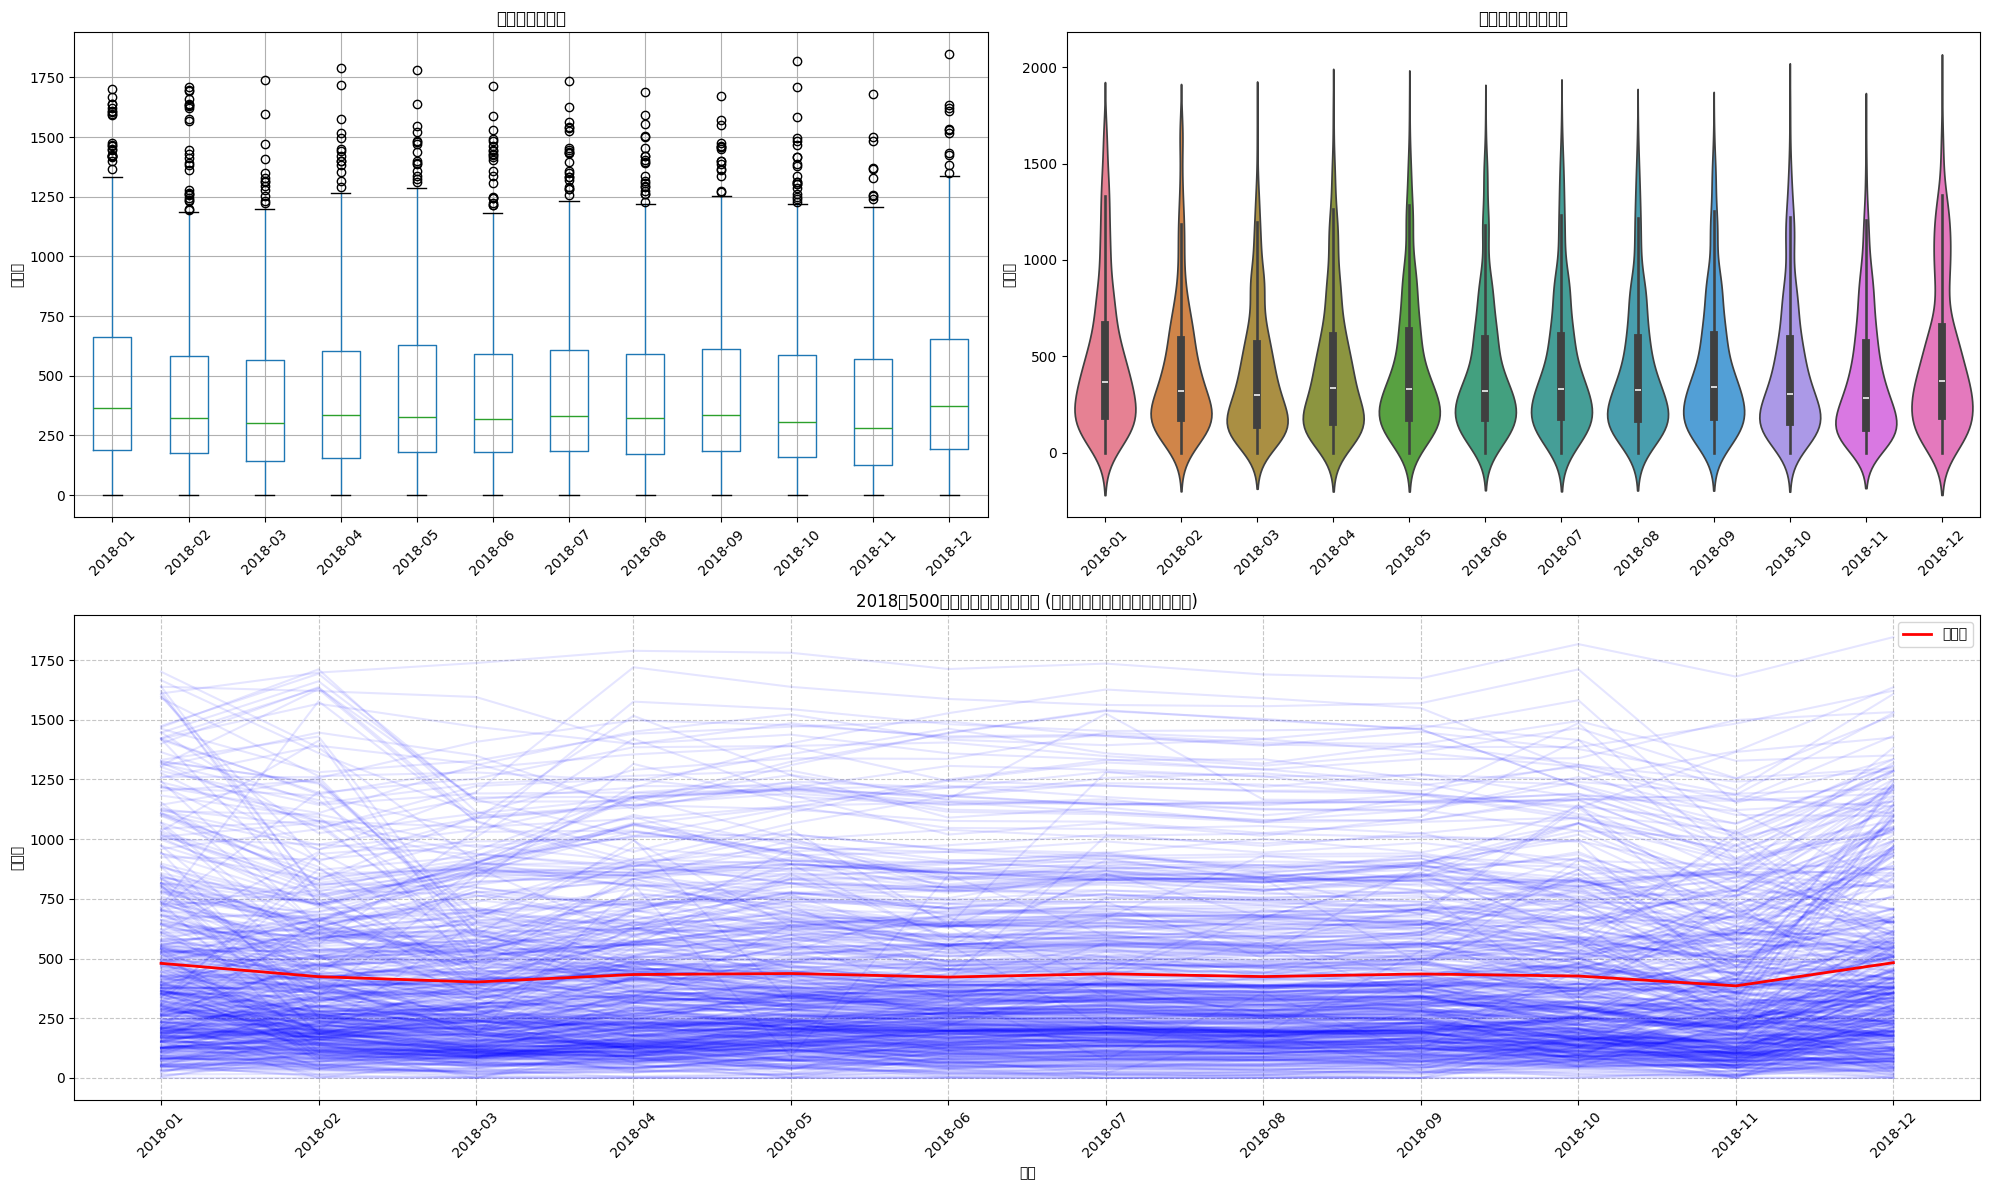


数据统计概览：
           2018-01      2018-02      2018-03      2018-04      2018-05  \
count   500.000000   500.000000   500.000000   500.000000   500.000000   
mean    479.753740   423.927633   401.461939   432.847211   437.106911   
std     382.767021   348.573090   325.399974   350.071101   350.625518   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%     191.080731   177.327105   142.105137   156.082022   179.002894   
50%     366.397659   321.395327   300.881654   335.015838   329.098057   
75%     660.509899   583.907694   564.609384   605.236844   628.835496   
max    1701.531314  1711.308199  1737.777682  1789.000597  1780.736833   

           2018-06      2018-07      2018-08      2018-09      2018-10  \
count   500.000000   500.000000   500.000000   500.000000   500.000000   
mean    422.275871   435.850907   424.238302   435.195727   426.552808   
std     338.862163   348.687429   340.775879   341.862325   351.657955   
min       0.000000     0.000

In [16]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def extract_nonzero_points(raster_path, num_points=500):
    """提取非零点位的时间序列数据"""
    with rasterio.open(raster_path) as src:
        # 读取所有波段数据
        data = src.read()
        
        # 获取非零且非NaN的有效数据位置（使用所有波段的平均值）
        mean_data = np.mean(data, axis=0)
        valid_mask = (mean_data > 0) & ~np.isnan(mean_data)
        valid_positions = np.where(valid_mask)
        
        # 确保有足够的有效点位
        num_valid = len(valid_positions[0])
        if num_valid < num_points:
            print(f"警告：只找到 {num_valid} 个有效点位")
            num_points = num_valid
            
        # 随机选择点位
        selected_indices = np.random.choice(num_valid, num_points, replace=False)
        
        # 提取数据
        time_series = []
        coordinates = []
        
        for idx in selected_indices:
            row = valid_positions[0][idx]
            col = valid_positions[1][idx]
            
            # 获取地理坐标
            x, y = src.xy(row, col)
            coordinates.append((x, y))
            
            # 获取所有波段的值
            values = [data[band, row, col] for band in range(data.shape[0])]
            time_series.append(values)
            
        return np.array(time_series), coordinates

# 读取数据
raster_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined_masked.tif'

# 提取数据点
n_points = 500
time_series, coordinates = extract_nonzero_points(raster_path, n_points)

# 创建月份标签
months = [f'2018-{i:02d}' for i in range(1, 13)]

# 创建DataFrame
df = pd.DataFrame(time_series, columns=months)

# 创建多个可视化图表
fig = plt.figure(figsize=(20, 12))

# 1. 箱型图
plt.subplot(221)
df.boxplot()
plt.xticks(rotation=45)
plt.title('月度用电量分布')
plt.ylabel('用电量')

# 2. 小提琴图
plt.subplot(222)
sns.violinplot(data=df)
plt.xticks(rotation=45)
plt.title('月度用电量密度分布')
plt.ylabel('用电量')

# 3. 时间序列图（使用半透明度显示所有点位）
plt.subplot(212)
for i in range(len(time_series)):
    plt.plot(months, time_series[i], alpha=0.1, color='blue')

# 添加均值线
mean_values = df.mean()
plt.plot(months, mean_values, color='red', linewidth=2, label='平均值')

plt.xlabel('月份')
plt.ylabel('用电量')
plt.title(f'2018年{n_points}个点位月度用电量变化 (蓝线为个体点位，红线为平均值)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# 打印统计信息
print("\n数据统计概览：")
print(df.describe())

# 保存数据到CSV文件（可选）
output_csv = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\monthly_electricity_500points.csv'
df.to_csv(output_csv)
print(f"\n数据已保存至：{output_csv}")

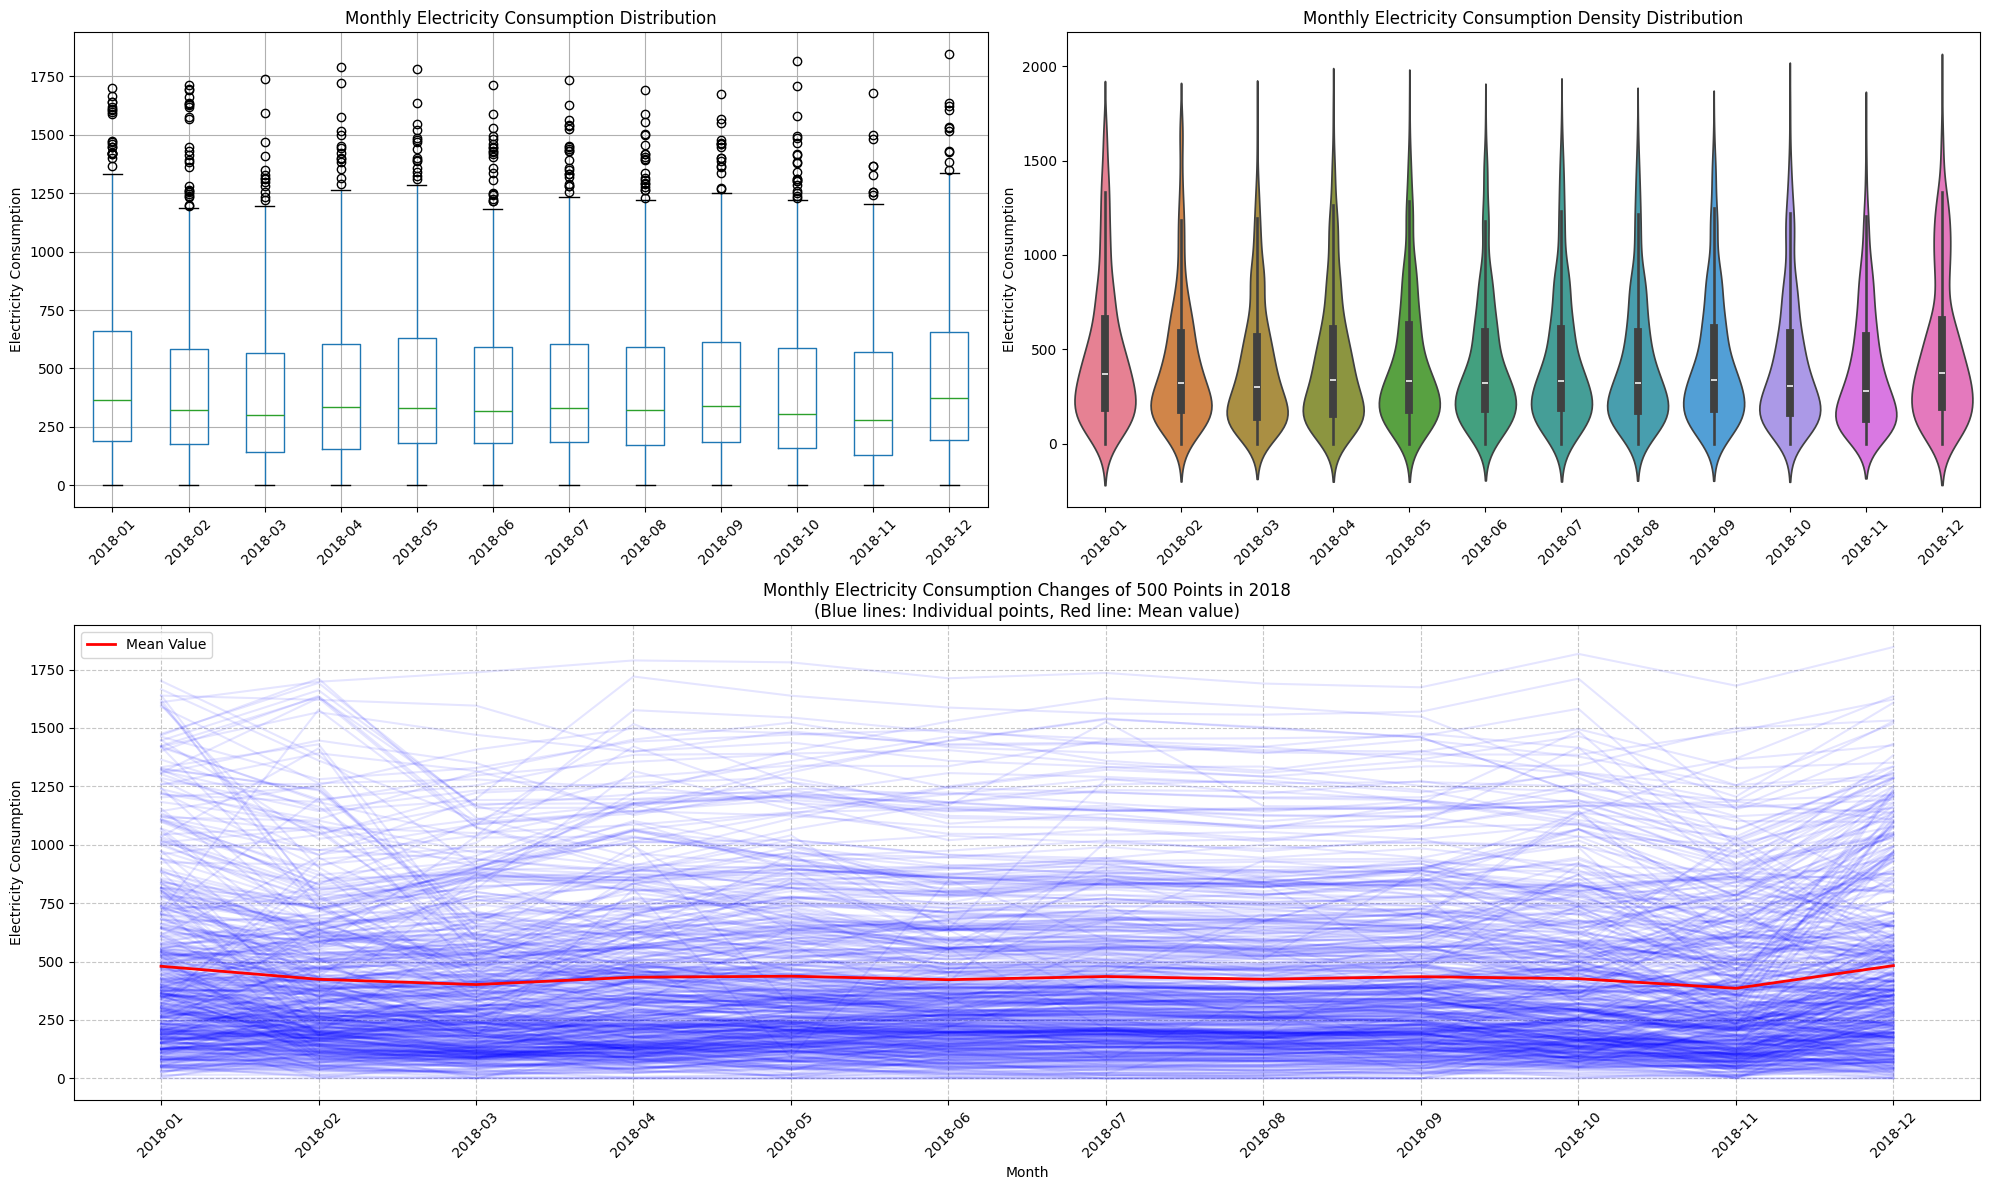


Statistical Overview:
           2018-01      2018-02      2018-03      2018-04      2018-05  \
count   500.000000   500.000000   500.000000   500.000000   500.000000   
mean    479.753740   423.927633   401.461939   432.847211   437.106911   
std     382.767021   348.573090   325.399974   350.071101   350.625518   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%     191.080731   177.327105   142.105137   156.082022   179.002894   
50%     366.397659   321.395327   300.881654   335.015838   329.098057   
75%     660.509899   583.907694   564.609384   605.236844   628.835496   
max    1701.531314  1711.308199  1737.777682  1789.000597  1780.736833   

           2018-06      2018-07      2018-08      2018-09      2018-10  \
count   500.000000   500.000000   500.000000   500.000000   500.000000   
mean    422.275871   435.850907   424.238302   435.195727   426.552808   
std     338.862163   348.687429   340.775879   341.862325   351.657955   
min       0.00

In [17]:
# ...existing code...

# 创建多个可视化图表
fig = plt.figure(figsize=(20, 12))

# 1. 箱型图
plt.subplot(221)
df.boxplot()
plt.xticks(rotation=45)
plt.title('Monthly Electricity Consumption Distribution')
plt.ylabel('Electricity Consumption')

# 2. 小提琴图
plt.subplot(222)
sns.violinplot(data=df)
plt.xticks(rotation=45)
plt.title('Monthly Electricity Consumption Density Distribution')
plt.ylabel('Electricity Consumption')

# 3. 时间序列图（使用半透明度显示所有点位）
plt.subplot(212)
for i in range(len(time_series)):
    plt.plot(months, time_series[i], alpha=0.1, color='blue')

# 添加均值线
mean_values = df.mean()
plt.plot(months, mean_values, color='red', linewidth=2, label='Mean Value')

plt.xlabel('Month')
plt.ylabel('Electricity Consumption')
plt.title(f'Monthly Electricity Consumption Changes of {n_points} Points in 2018\n(Blue lines: Individual points, Red line: Mean value)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# 打印统计信息
print("\nStatistical Overview:")
print(df.describe())

# 保存数据到CSV文件（可选）
output_csv = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\monthly_electricity_500points.csv'
df.to_csv(output_csv)
print(f"\nData saved to: {output_csv}")